In [3]:
import numpy as np

# Load directional flow outputs (each is 125x3)
Fz = np.loadtxt("flow_out_z_step1.dat", delimiter=",")[:, 2]
Fx = np.loadtxt("flow_out_x_step1.dat", delimiter=",")[:, 0]
Fy = np.loadtxt("flow_out_y_step1.dat", delimiter=",")[:, 1]

# Stack to match sliced_realizations_375 ordering
flow_375 = np.concatenate([Fz, Fx, Fy], axis=0)

print("Stacked flow shape:", flow_375.shape)  # should be (375,)

# Save for ML use
np.save("flow_target_375.npy", flow_375)


Stacked flow shape: (375,)


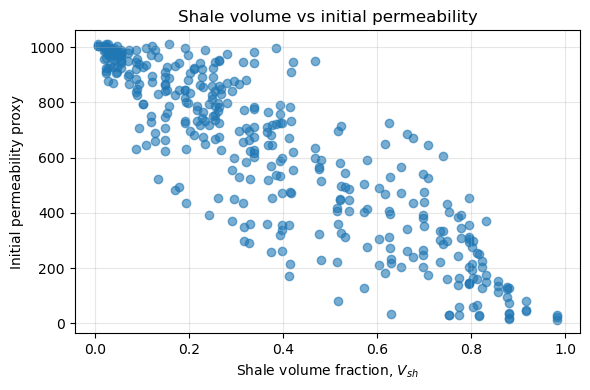

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# Load data
# ----------------------------------------
# CSV containing shale volume for 375 sliced realizations
shale_df = pd.read_csv("shale_volume_sliced_375.csv")

# NPY file containing stacked flow (permeability proxy)
flow = np.load("flow_target_375.npy")

# ----------------------------------------
# Extract variables
# ----------------------------------------
Vsh = shale_df["Vsh"].values           # shale volume fraction
k0  = flow                             # initial permeability proxy

# ----------------------------------------
# Plot
# ----------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(Vsh, k0, alpha=0.6)
plt.xlabel("Shale volume fraction, $V_{sh}$")
plt.ylabel("Initial permeability proxy")
plt.title("Shale volume vs initial permeability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


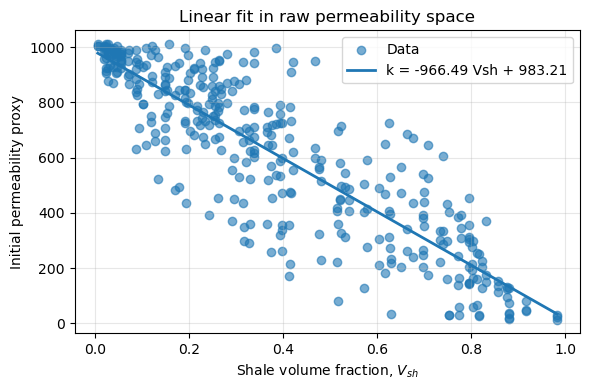

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
shale_df = pd.read_csv("shale_volume_sliced_375.csv")
flow = np.load("flow_target_375.npy")

Vsh = shale_df["Vsh"].values
k0  = flow

# Linear fit: k = m*Vsh + c
m, c = np.polyfit(Vsh, k0, 1)

# Fit line
Vsh_fit = np.linspace(Vsh.min(), Vsh.max(), 200)
k_fit = m * Vsh_fit + c

# Plot
plt.figure(figsize=(6,4))
plt.scatter(Vsh, k0, alpha=0.6, label="Data")
plt.plot(Vsh_fit, k_fit, linewidth=2, label=f"k = {m:.2f} Vsh + {c:.2f}")
plt.xlabel("Shale volume fraction, $V_{sh}$")
plt.ylabel("Initial permeability proxy")
plt.title("Linear fit in raw permeability space")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
